In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import linalg
from scipy.interpolate import lagrange
from numpy.polynomial.legendre import leggauss

In [2]:
def mat(k=1,p=2):

    # gauss legendre quadrature points
    if (p > 0):
        x_inner, _ = leggauss(p)
    xf = np.zeros(p+2)
    xf[0] = -1
    xf[p+1] = +1
    if (p > 0):
        xf[1:-1] = x_inner
 
    # equidistant points
#    xf = np.linspace(-1,1,p+2)
    
    M=np.zeros([p+1,p+1],dtype=complex)
    z=1j
    
    for i in range(0,p+1):
        for j in range(0,p+1):
            
            f = np.zeros(p+2)
            f[j+1] = 1.0            
            g = lagrange(xf,f)
            g_prime = g.deriv()
            
            M[i,j] = -2*g_prime(xf[i+1])

        f = np.zeros(p+2)
        f[0] = 1.0            
        g = lagrange(xf,f)
        g_prime = g.deriv()

        M[i,p] = M[i,p] -2*g_prime(xf[i+1])*np.exp(-z*k)
        
    return M

def mod_wave_sd(p,n):
    k = np.linspace(-np.pi+1e-4,np.pi-1e-4,n)
    l = np.zeros((n,p+1),dtype=complex)
    for i in range(0,n):
        M = mat(k=k[i],p=p)
        evalues, evectors = linalg.eig(M)
        ind = np.argsort(abs(evalues))
        l[i] = evalues[ind]

    bin_k = []
    rel_k = []
    img_k = []
    # -imaginary part 
    for j in range(0,(p+1)):
        iml = -l[:,j].imag
        ind = np.where(iml>0)
        kk = k + (j+1)//2*(2*np.pi)
        bin_k = np.append(bin_k,kk[ind])
        img_k = np.append(img_k,iml[ind])
    for j in range(0,(p+1)):
        iml = -l[:,j].imag
        ind = np.where(iml<0)
        kk = k - (j+1)//2*(2*np.pi)
        bin_k = np.append(bin_k,kk[ind])
        img_k = np.append(img_k,iml[ind])

    # +real part
    for j in range(0,(p+1)):
        iml = -l[:,j].imag
        rel = l[:,j].real
        ind = np.where(iml>0)
        kk = k + (j+1)//2*(2*np.pi)
        rel_k = np.append(rel_k, rel[ind])
    for j in range(0,(p+1)):
        iml = -l[:,j].imag
        rel = l[:,j].real
        ind = np.where(iml<0)
        kk = k - (j+1)//2*(2*np.pi)
        rel_k = np.append(rel_k, rel[ind])

    ind=np.argsort(bin_k)
    return bin_k[ind], rel_k[ind], img_k[ind]

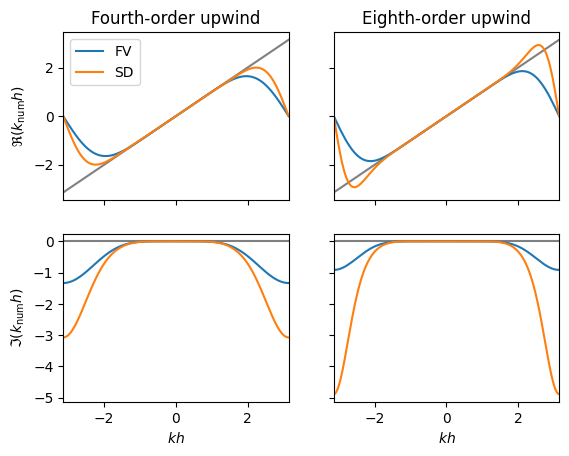

In [3]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey='row')
axs[0, 0].set_xlim([-np.pi,np.pi])
axs[1, 0].set_xlabel(r"$k h$")
axs[1, 1].set_xlabel(r"$k h$")
axs[0, 0].set_ylabel(r"$\Re(k_{\rm num}h)$")
axs[1, 0].set_ylabel(r"$\Im(k_{\rm num}h)$")
axs[0, 0].set_title("Fourth-order upwind")
axs[0, 1].set_title("Eighth-order upwind")

k=np.linspace(-np.pi,np.pi,100)

for j in range(2):
    axs[0, j].plot(k,k,color='grey')
    axs[1, j].plot(k,0.+0.*k,color="grey")

# fourth-order upwind FV
y=(+np.sin(3*k)-7*np.sin(2*k)+26*np.sin(k)   +11*np.sin(k)-np.sin(2*k))/24.
axs[0, 0].plot(k,y,"-",mfc="none", label="FV")

x=-(-np.cos(3*k)+7*np.cos(2*k)-26*np.cos(k)+10+11*np.cos(k)-np.cos(2*k))/24.
axs[1, 0].plot(k,x,"-",mfc="none", label="FV")

# fourth-order upwind SD
p = 3
k, rel, img = mod_wave_sd(p,100)
axs[0, 0].plot(k/(p+1), img/(p+1), label="SD")
axs[1, 0].plot(k/(p+1), rel/(p+1), label="SD")

# eigth-order upwind FV
y=(+3*np.sin(5*k)-33*np.sin(4*k)+172*np.sin(3*k)-588*np.sin(2*k)+1722*np.sin(k)+1092*np.sin(k)-228*np.sin(2*k)+37*np.sin(3*k)-3*np.sin(4*k))/1680.
axs[0, 1].plot(k,y,"-",mfc="none", label="FV")

x=-(-3*np.cos(5*k)+33*np.cos(4*k)-172*np.cos(3*k)+588*np.cos(2*k)-1722*np.cos(k)+378+1092*np.cos(k)-228*np.cos(2*k)+37*np.cos(3*k)-3*np.cos(4*k))/1680.
axs[1, 1].plot(k,x,"-",mfc="none", label="FV")

# eighth-order upwind SD
p = 7
k, rel, img = mod_wave_sd(p,100)
axs[0, 1].plot(k/(p+1), img/(p+1), label="SD")
axs[1, 1].plot(k/(p+1), rel/(p+1), label="SD")

axs[0, 0].legend()

fig.savefig("modified_wavenumber_analysis.pdf")

In [4]:
def l2(x):
    return np.sqrt(np.mean(np.square(x)))

def spectral_l2_integrand(k, phase_err, diss_err):
    integrand = phase_err**2 + diss_err**2
    return integrand

def spectral_l2(k, phase_err, diss_err):
    integrand = spectral_l2_integrand(k, phase_err, diss_err)
    return np.sqrt(np.trapezoid(integrand, k) / (k[-1] - k[0]))

Spectral L2 error FV 4th order:  1.2220863472919954
Spectral L2 error FV 8th order:  1.019106860714106
Spectral L2 error SD 4th order:  1.565279768356568
Spectral L2 error SD 8th order:  1.8115662684229081


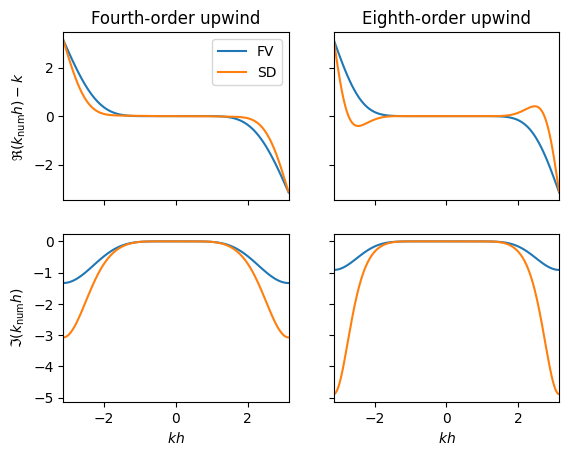

In [5]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey='row')
axs[0, 0].set_xlim([-np.pi,np.pi])
axs[1, 0].set_xlabel(r"$k h$")
axs[1, 1].set_xlabel(r"$k h$")
axs[0, 0].set_ylabel(r"$\Re(k_{\rm num}h) - k$")
axs[1, 0].set_ylabel(r"$\Im(k_{\rm num}h)$")
axs[0, 0].set_title("Fourth-order upwind")
axs[0, 1].set_title("Eighth-order upwind")

k=np.linspace(-np.pi,np.pi,100)

# fourth-order upwind FV
y=(+np.sin(3*k)-7*np.sin(2*k)+26*np.sin(k)   +11*np.sin(k)-np.sin(2*k))/24.
axs[0, 0].plot(k,y-k,"-",mfc="none", label="FV")

x=-(-np.cos(3*k)+7*np.cos(2*k)-26*np.cos(k)+10+11*np.cos(k)-np.cos(2*k))/24.
axs[1, 0].plot(k,x,"-",mfc="none", label="FV")
# print("L2 error FV 4th order (real, imag): ", l2(y-k), l2(x))
print("Spectral L2 error FV 4th order: ", spectral_l2(k, y-k, x))

# eigth-order upwind FV
y=(+3*np.sin(5*k)-33*np.sin(4*k)+172*np.sin(3*k)-588*np.sin(2*k)+1722*np.sin(k)+1092*np.sin(k)-228*np.sin(2*k)+37*np.sin(3*k)-3*np.sin(4*k))/1680.
axs[0, 1].plot(k,y-k,"-",mfc="none", label="FV")

x=-(-3*np.cos(5*k)+33*np.cos(4*k)-172*np.cos(3*k)+588*np.cos(2*k)-1722*np.cos(k)+378+1092*np.cos(k)-228*np.cos(2*k)+37*np.cos(3*k)-3*np.cos(4*k))/1680.
axs[1, 1].plot(k,x,"-",mfc="none", label="FV")
# print("L2 error FV 8th order (real, imag): ", l2(y-k), l2(x))
print("Spectral L2 error FV 8th order: ", spectral_l2(k, y-k, x))

# fourth-order upwind SD
p = 3
k, rel, img = mod_wave_sd(p,100)
axs[0, 0].plot(k/(p+1), img/(p+1)-k/(p+1), label="SD")
axs[1, 0].plot(k/(p+1), rel/(p+1), label="SD")
# print("L2 error SD 4th order (real, imag): ", l2(img/(p+1)-k/(p+1)), l2(rel/(p+1)))
print("Spectral L2 error SD 4th order: ", spectral_l2(k/(p+1), img/(p+1)-k/(p+1), rel/(p+1)))

# eighth-order upwind SD
p = 7
k, rel, img = mod_wave_sd(p,100)
axs[0, 1].plot(k/(p+1), img/(p+1)-k/(p+1), label="SD")
axs[1, 1].plot(k/(p+1), rel/(p+1), label="SD")
# print("L2 error SD 8th order (real, imag): ", l2(img/(p+1)-k/(p+1)), l2(rel/(p+1)))
print("Spectral L2 error SD 8th order: ", spectral_l2(k/(p+1), img/(p+1)-k/(p+1), rel/(p+1)))

axs[0, 0].legend()

fig.savefig("modified_wavenumber_analysis_error.pdf")

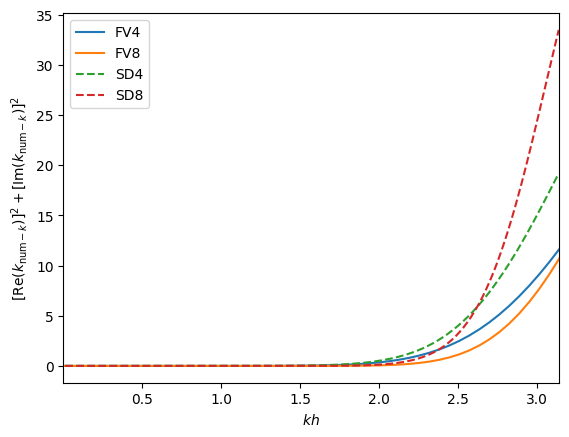

In [9]:
fig, ax = plt.subplots()
ax.set_xlim([1e-4,np.pi])
ax.set_xlabel(r"$k h$")
ax.set_ylabel(r"$[ \operatorname{Re} (k_{\text{num} - k}) ]^2 + [ \operatorname{Im} (k_{\text{num} - k}) ]^2$")

k=np.linspace(-np.pi,np.pi,100)

# fourth-order upwind FV
y=(+np.sin(3*k)-7*np.sin(2*k)+26*np.sin(k)   +11*np.sin(k)-np.sin(2*k))/24.
x=-(-np.cos(3*k)+7*np.cos(2*k)-26*np.cos(k)+10+11*np.cos(k)-np.cos(2*k))/24.
integrand = spectral_l2_integrand(k, y-k, x)
ax.plot(k, integrand, "-", mfc="none", label="FV4")

# eigth-order upwind FV
y=(+3*np.sin(5*k)-33*np.sin(4*k)+172*np.sin(3*k)-588*np.sin(2*k)+1722*np.sin(k)+1092*np.sin(k)-228*np.sin(2*k)+37*np.sin(3*k)-3*np.sin(4*k))/1680.
x=-(-3*np.cos(5*k)+33*np.cos(4*k)-172*np.cos(3*k)+588*np.cos(2*k)-1722*np.cos(k)+378+1092*np.cos(k)-228*np.cos(2*k)+37*np.cos(3*k)-3*np.cos(4*k))/1680.
integrand = spectral_l2_integrand(k, y-k, x)
ax.plot(k, integrand, "-", mfc="none", label="FV8")

# fourth-order upwind SD
p = 3
k, rel, img = mod_wave_sd(p,100)
integrand = spectral_l2_integrand(k/(p+1), img/(p+1)-k/(p+1), rel/(p+1))
ax.plot(k/(p+1), integrand, "--", mfc="none", label="SD4")

# eighth-order upwind SD
p = 7
k, rel, img = mod_wave_sd(p,100)
integrand = spectral_l2_integrand(k/(p+1), img/(p+1)-k/(p+1), rel/(p+1))
ax.plot(k/(p+1), integrand, "--", mfc="none", label="SD8")

ax.legend()

fig.savefig("modified_wavenumber_analysis_integrand.pdf")